# Attribution Maps for Suffix Prediction Model

This notebook demonstrates how to compute and visualize attribution maps using three methods:

1. **Integrated Gradients** - Gradient-based (Sundararajan et al., 2017)
2. **SHAP** - Shapley values using permutation sampling
3. **ICE** - Individual Conditional Expectations (sensitivity analysis)

An attribution map shows how much each input feature at each prefix step contributes to the model's prediction.

## 1. Setup

In [1]:
import sys
import torch
import matplotlib.pyplot as plt

# Add parent directories to path
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

# Import model and interpretability tool
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from interpretability import InterpretabilityTool

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. Load Model and Data

In [2]:
# Load the trained model
model_path = '../../notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(model_path, dropout=0.0)
model.eval()
model = model.to(device)

print(f"Model loaded successfully!")
print(f"Sequence length prediction: {model.seq_len_pred}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [3]:
# Load the test dataset
data_path = '../../../encoded_data/test_philipp/helpdesk_all_5_test.pkl'
test_dataset = torch.load(data_path, weights_only=False)

print(f"Dataset loaded with {len(test_dataset)} samples")

Dataset loaded with 6077 samples


## 3. Initialize Interpretability Tool

In [4]:
# Initialize the interpretability tool
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

# Show available targets
targets = tool.get_available_targets()
print("Available targets for explanation:")
print(f"  Categorical: {targets['categorical']}")
print(f"  Numerical: {targets['numerical']}")

Available targets for explanation:
  Categorical: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
  Numerical: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


In [5]:
# Select a process from the test dataset
process_idx = 10
sample = test_dataset[process_idx]

# Extract process data (categorical and numerical tensors)
process = (sample[0], sample[1])

# Show process length
process_length = sample[0][0].shape[0]
print(f"Process {process_idx} has {process_length} events")

Process 10 has 18 events


## 4. Attribution Methods

The `compute_attribution_map` method supports three methods:
- `method='integrated_gradients'` - Gradient-based, theoretically grounded
- `method='shap'` - Game-theoretic, model-agnostic
- `method='ice'` - Sensitivity analysis, fast

### 4.1 Integrated Gradients

Integrated Gradients (Sundararajan et al., 2017) computes attributions by integrating gradients along the path from a baseline to the input. It satisfies important axioms like sensitivity and completeness.

In [6]:
# Compute using Integrated Gradients
attr_ig = tool.compute_attribution_map(
    process=process,
    prefix_length=4,
    target='Activity',
    target_class='auto',
    suffix_scope='next',
    method='integrated_gradients',
    n_steps=50
)

print(attr_ig)
print()
print(attr_ig.to_string())

AttributionMap(
  target: Activity = EOS (class 5) [integrated_gradients]
  shape: (16, 4) (features x steps)
  prefix_length: 4
  suffix_scope: next
  convergence_delta: 0.000052
)

ATTRIBUTION MAP: Activity = EOS (class 5) [integrated_gradients]
Prefix length: 4 | Suffix scope: next
Convergence delta: 0.000052

                      Assign ser..Take in ch..Resolve ti..      Closed
----------------------------------------------------------------------
            Activity |      0.0015      0.0024      0.0037      0.0050
            Resource |      0.0013      0.0013      0.0010      0.0019
       Variant index |      0.0034      0.0035      0.0039      0.0046
         seriousness |      0.0006      0.0005      0.0006      0.0016
            customer |      0.0016      0.0017      0.0020      0.0035
             product |      0.0007      0.0007      0.0007      0.0013
 responsible_section |      0.0006      0.0007      0.0008      0.0010
       seriousness_2 |      0.0003      0.0003

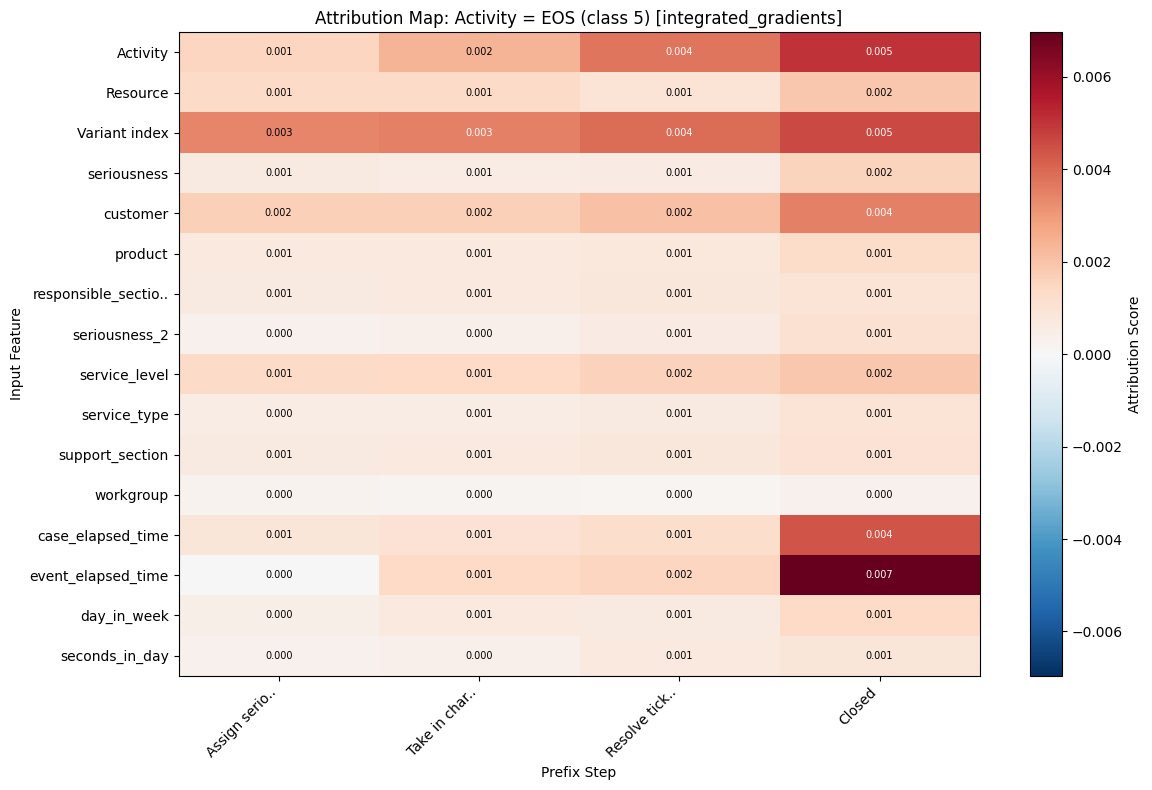

In [7]:
# Visualize Integrated Gradients
fig, ax = attr_ig.plot(figsize=(12, 8), show_values=True)
plt.show()

### 4.2 SHAP (Sequence-Aware)

SHAP (SHapley Additive exPlanations) uses game-theoretic Shapley values to measure each feature's contribution. This implementation uses permutation sampling adapted for sequential data.

In [8]:
# Compute using SHAP
attr_shap = tool.compute_attribution_map(
    process=process,
    prefix_length=4,
    target='Activity',
    target_class='auto',
    suffix_scope='next',
    method='shap',
    n_samples=50  # More samples = more accurate but slower
)

print(attr_shap)
print()
print(attr_shap.to_string())

AttributionMap(
  target: Activity = EOS (class 5) [shap]
  shape: (16, 4) (features x steps)
  prefix_length: 4
  suffix_scope: next
  convergence_delta: N/A
)

ATTRIBUTION MAP: Activity = EOS (class 5) [shap]
Prefix length: 4 | Suffix scope: next

                      Assign ser..Take in ch..Resolve ti..      Closed
----------------------------------------------------------------------
            Activity |      0.0033      0.0236      0.7097      0.5773
            Resource |      0.1639      0.2316      0.1596      0.3468
       Variant index |      1.0027      1.2151      1.5911      2.0607
         seriousness |      0.0591      0.0678      0.0437      0.0501
            customer |      0.4705      0.6079      0.8112      0.7425
             product |      0.1280      0.1497      0.1439      0.0615
 responsible_section |      0.1790      0.2201      0.2947      0.3971
       seriousness_2 |      0.0090      0.0072      0.0093      0.0417
       service_level |      0.0953      

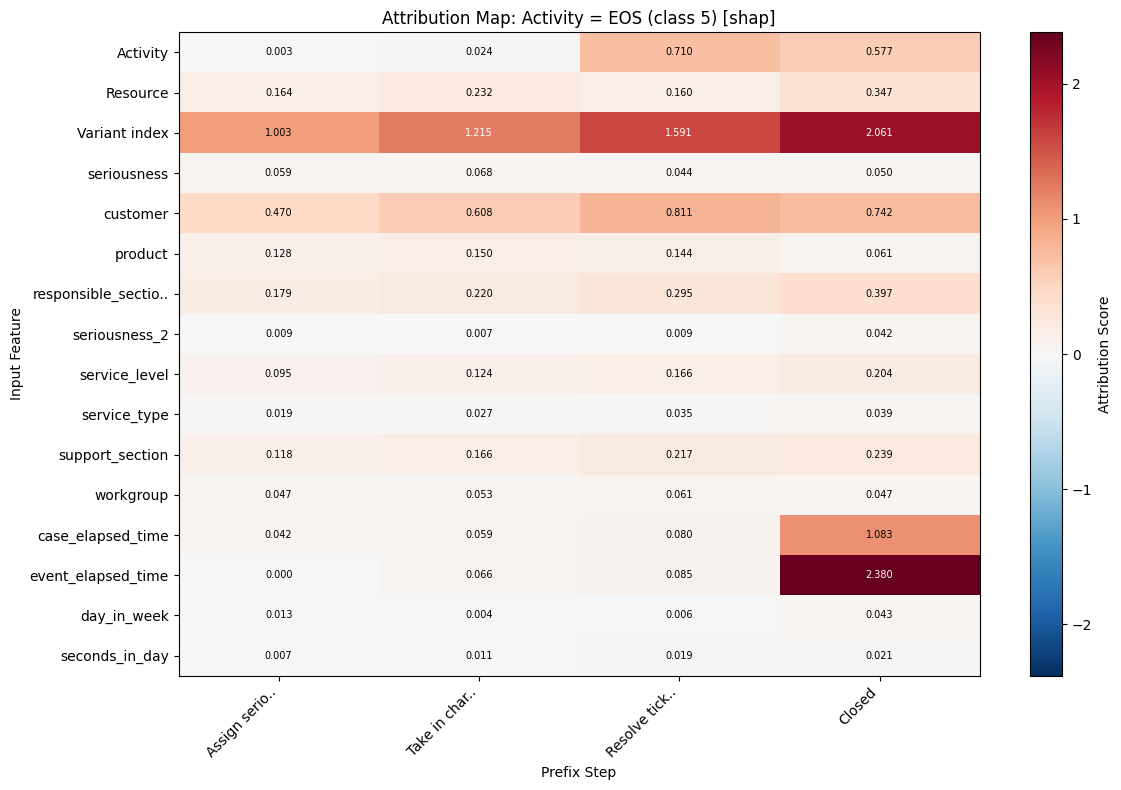

In [9]:
# Visualize SHAP values
fig, ax = attr_shap.plot(figsize=(12, 8), show_values=True)
plt.show()

### 4.3 ICE (Individual Conditional Expectations)

ICE measures feature sensitivity by perturbing each feature and observing the change in prediction. It's fast and intuitive but doesn't account for feature interactions.

In [10]:
# Compute using ICE
attr_ice = tool.compute_attribution_map(
    process=process,
    prefix_length=4,
    target='Activity',
    target_class='auto',
    suffix_scope='next',
    method='ice'
)

print(attr_ice)
print()
print(attr_ice.to_string())

AttributionMap(
  target: Activity = EOS (class 5) [ice]
  shape: (16, 4) (features x steps)
  prefix_length: 4
  suffix_scope: next
  convergence_delta: N/A
)

ATTRIBUTION MAP: Activity = EOS (class 5) [ice]
Prefix length: 4 | Suffix scope: next

                      Assign ser..Take in ch..Resolve ti..      Closed
----------------------------------------------------------------------
            Activity |      0.0001      0.0001      0.0019      0.0241
            Resource |      0.0014      0.0011      0.0003      0.0081
       Variant index |      0.0059      0.0042      0.0032      0.0027
         seriousness |      0.0004      0.0003      0.0001      0.0003
            customer |      0.0032      0.0027      0.0017      0.0010
             product |      0.0010      0.0007      0.0004      0.0002
 responsible_section |      0.0013      0.0010      0.0008      0.0007
       seriousness_2 |      0.0001      0.0000      0.0001      0.0001
       service_level |      0.0006      0.

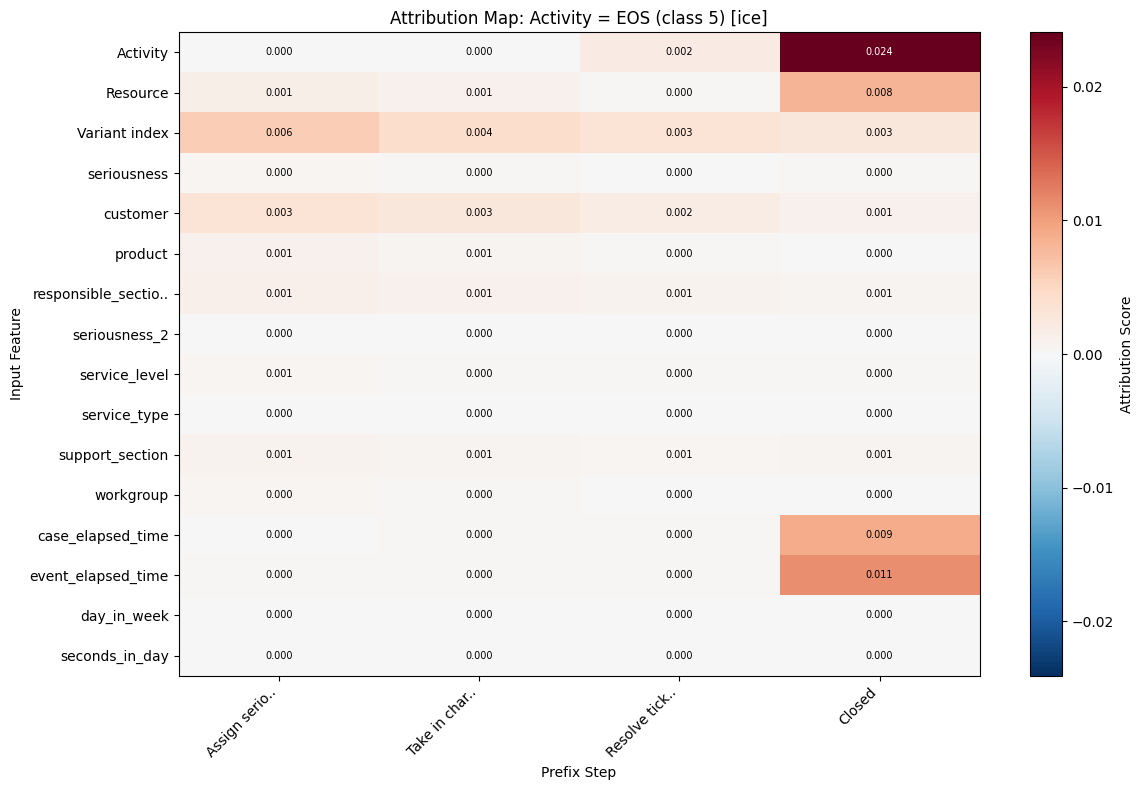

In [11]:
# Visualize ICE sensitivity
fig, ax = attr_ice.plot(figsize=(12, 8), show_values=True)
plt.show()

## 5. Compare Methods

Compare all three methods side by side.

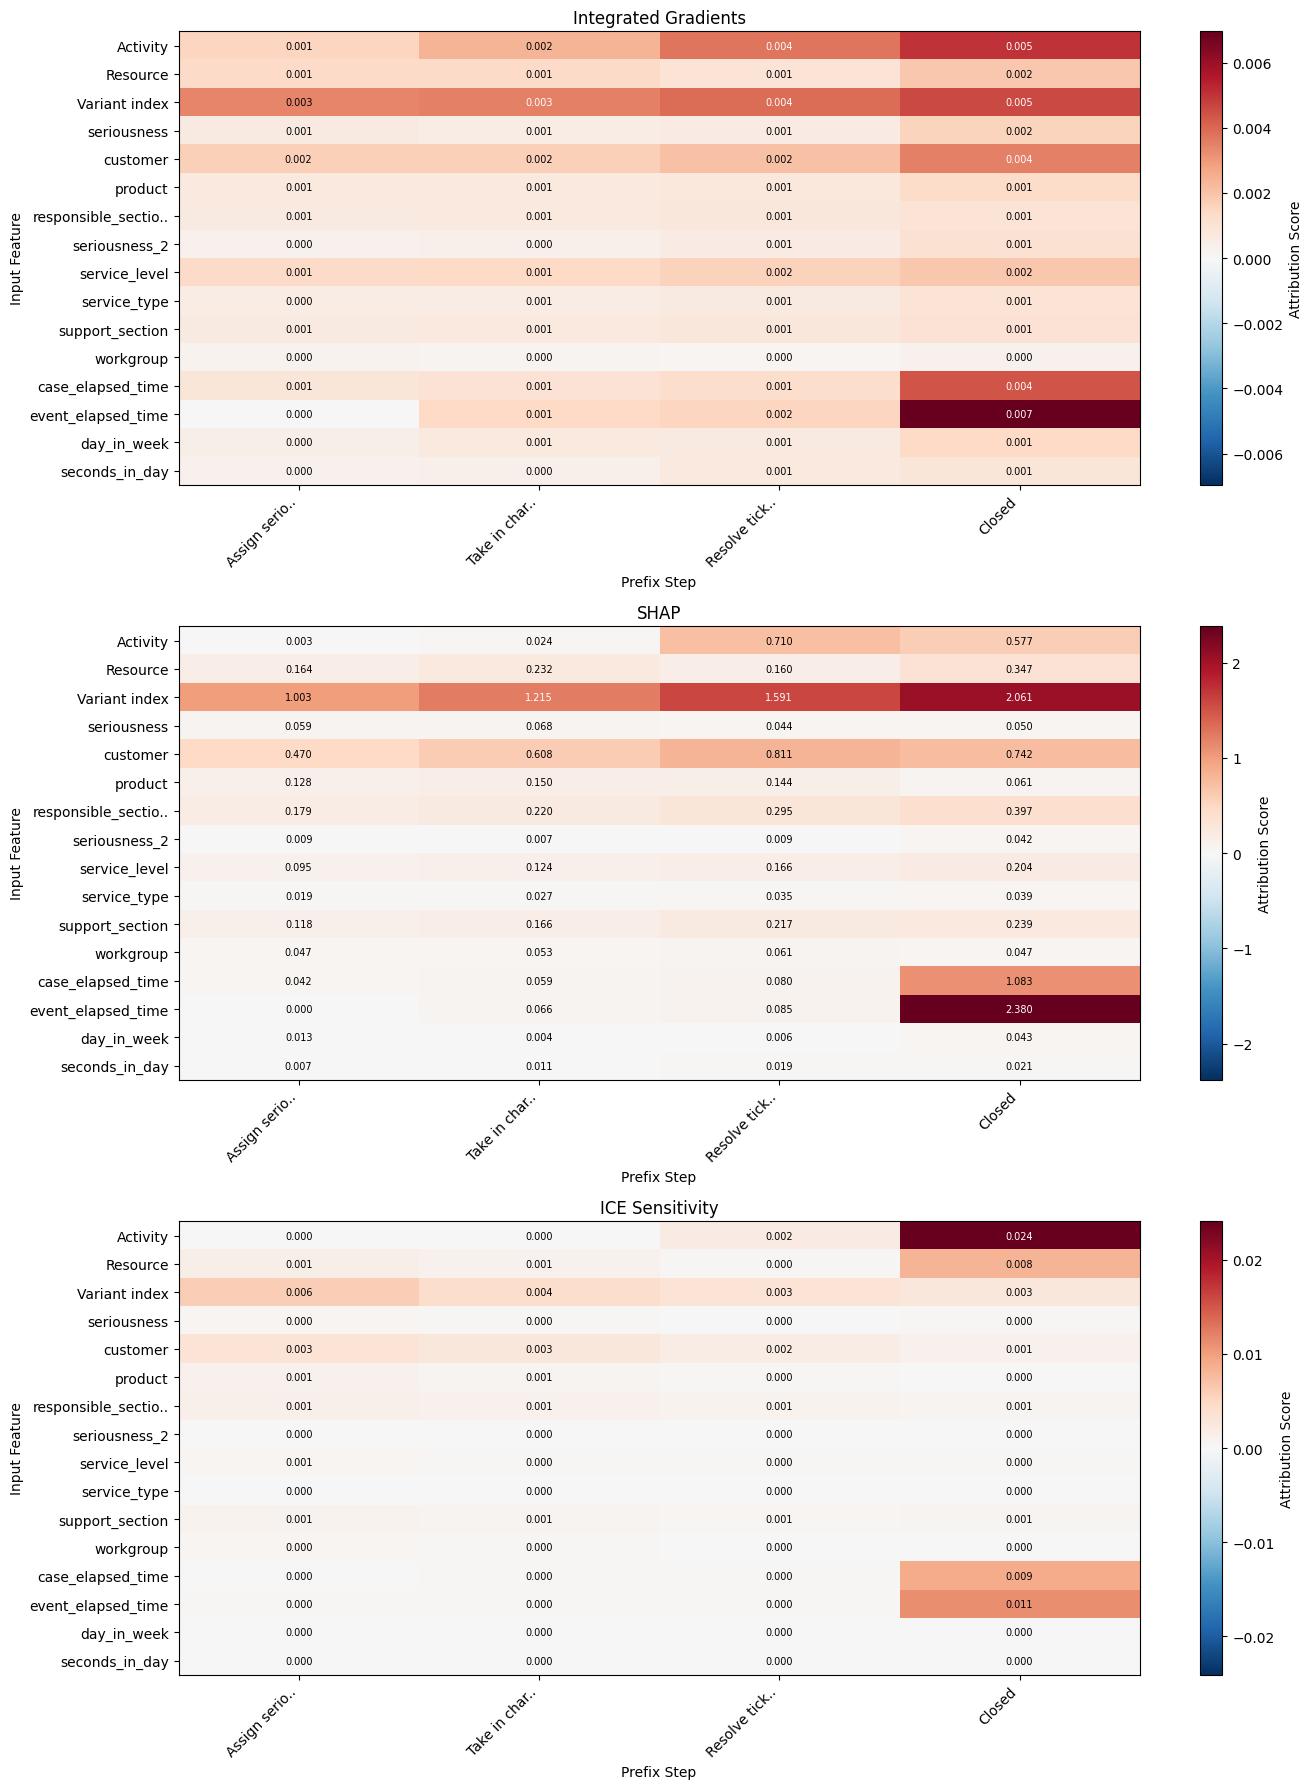

In [12]:
# Compare all three methods
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

attr_ig.plot(ax=axes[0], show_values=True, title="Integrated Gradients")
attr_shap.plot(ax=axes[1], show_values=True, title="SHAP")
attr_ice.plot(ax=axes[2], show_values=True, title="ICE Sensitivity")

plt.tight_layout()
plt.show()

## 6. Output Formats

All methods return an `AttributionMap` object with three output formats.

In [13]:
# 1. String output
print("=== String Output ===")
print(attr_ig.to_string())

# 2. Tensor output
print("\n=== Tensor Output ===")
tensor = attr_ig.to_tensor()
print(f"Shape: {tensor.shape} (features x prefix_steps)")
print(tensor)

# 3. NumPy output
print("\n=== NumPy Output ===")
arr = attr_ig.to_numpy()
print(f"Shape: {arr.shape}")
print(arr)

=== String Output ===
ATTRIBUTION MAP: Activity = EOS (class 5) [integrated_gradients]
Prefix length: 4 | Suffix scope: next
Convergence delta: 0.000052

                      Assign ser..Take in ch..Resolve ti..      Closed
----------------------------------------------------------------------
            Activity |      0.0015      0.0024      0.0037      0.0050
            Resource |      0.0013      0.0013      0.0010      0.0019
       Variant index |      0.0034      0.0035      0.0039      0.0046
         seriousness |      0.0006      0.0005      0.0006      0.0016
            customer |      0.0016      0.0017      0.0020      0.0035
             product |      0.0007      0.0007      0.0007      0.0013
 responsible_section |      0.0006      0.0007      0.0008      0.0010
       seriousness_2 |      0.0003      0.0003      0.0006      0.0010
       service_level |      0.0013      0.0014      0.0016      0.0019
        service_type |      0.0005      0.0005      0.0006      0

## 7. Numerical Targets

You can also explain numerical predictions like `case_elapsed_time`.

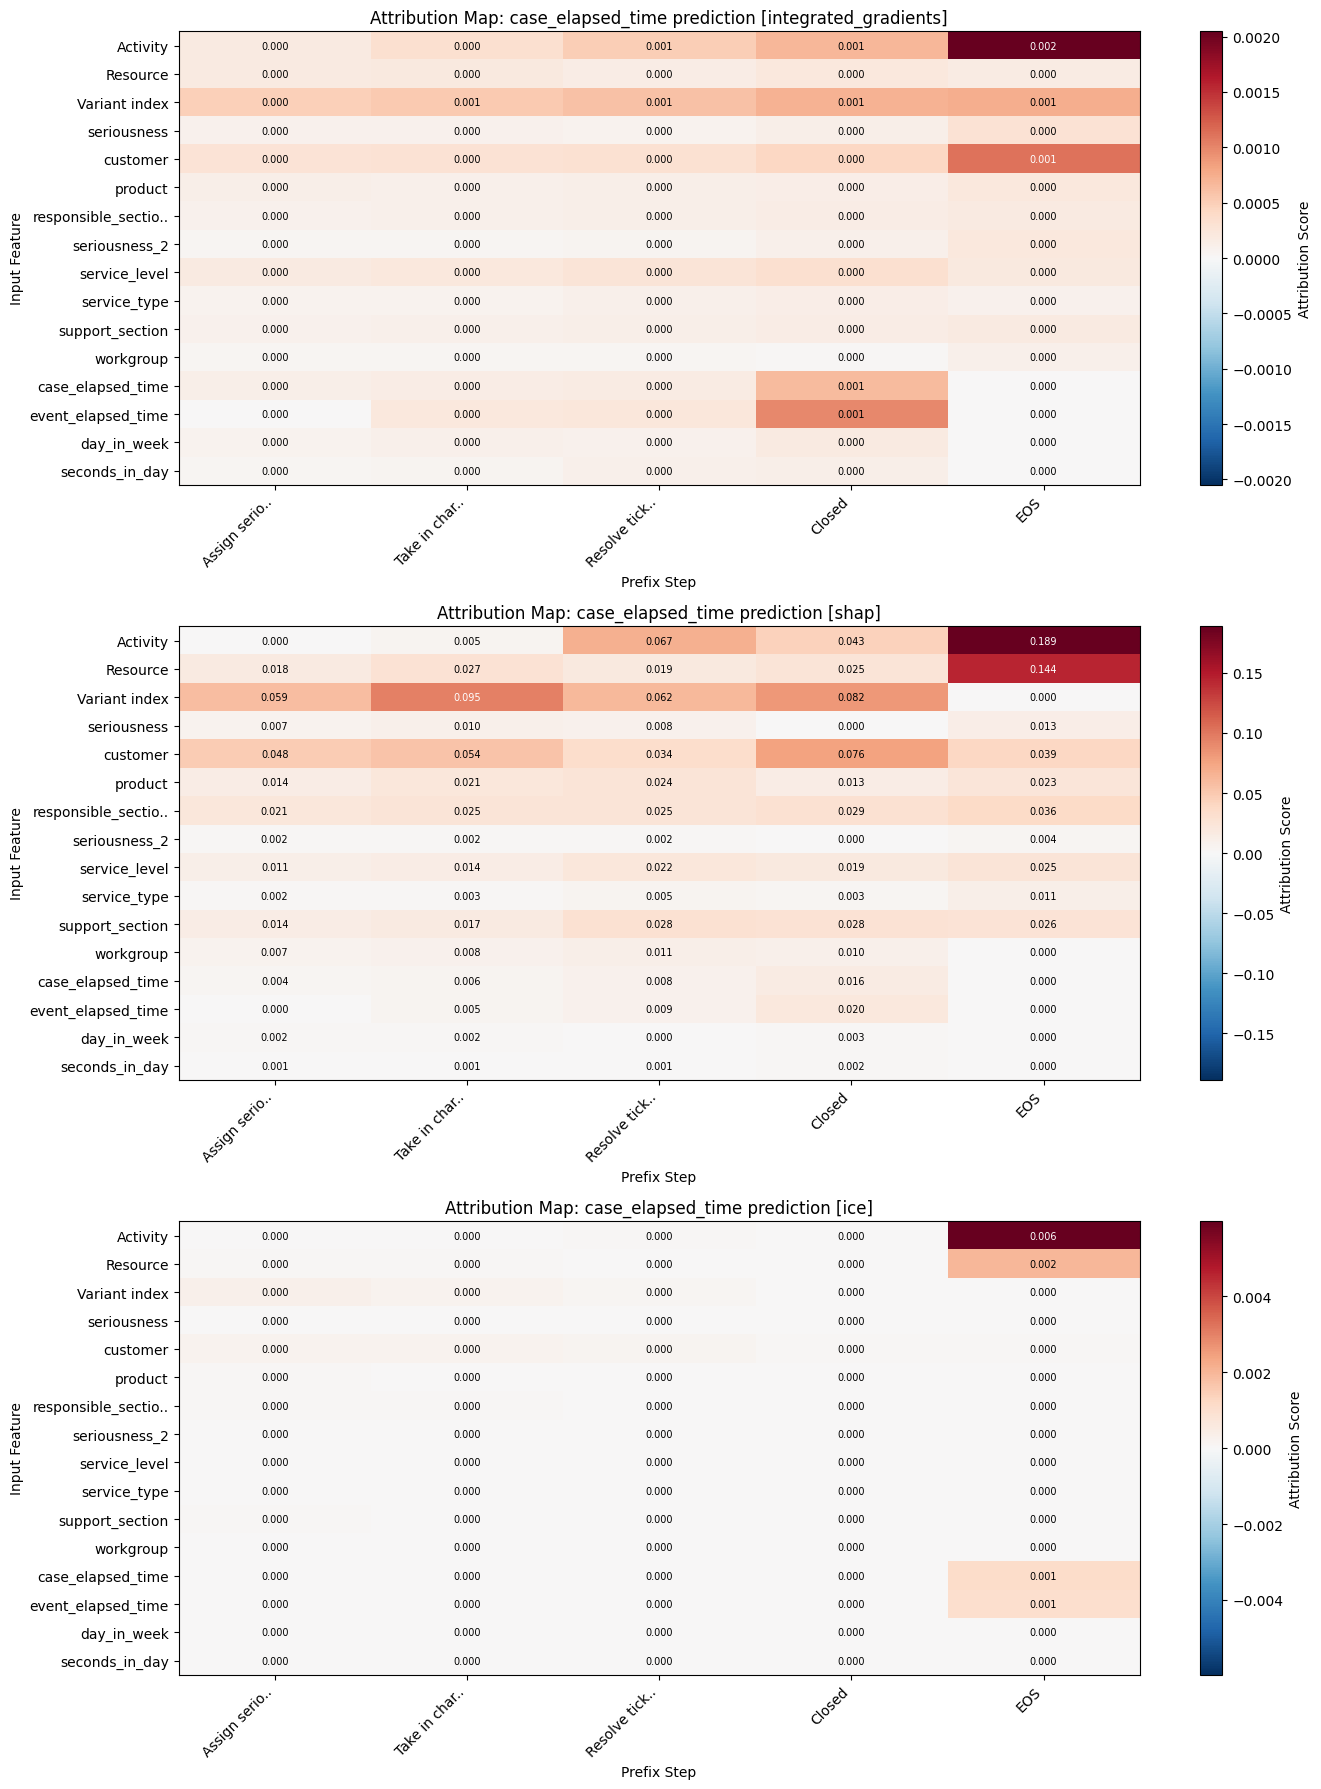

In [14]:
# Explain case_elapsed_time prediction using all three methods
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for i, method in enumerate(['integrated_gradients', 'shap', 'ice']):
    attr = tool.compute_attribution_map(
        process=process,
        prefix_length=5,
        target='case_elapsed_time',
        suffix_scope='next',
        method=method,
        n_steps=30,
        n_samples=30
    )
    attr.plot(ax=axes[i], show_values=True)

plt.tight_layout()
plt.show()

## Summary

### Method Selection Guide

| Method | Speed | Accuracy | Interactions | Use Case |
|--------|-------|----------|--------------|----------|
| **Integrated Gradients** | Medium | High | Yes | Theoretically grounded explanations |
| **SHAP** | Slow | High | Yes | Game-theoretic fairness |
| **ICE** | Fast | Medium | No | Quick sensitivity analysis |

### API Reference

```python
attr_map = tool.compute_attribution_map(
    process=process,          # Full process from dataset
    prefix_length=5,          # First N events are prefix
    target='Activity',        # What to explain
    target_class='auto',      # Which class (or 'auto' for predicted)
    suffix_scope='next',      # 'next' or 'full'
    method='integrated_gradients',  # 'integrated_gradients', 'shap', or 'ice'
    n_steps=50,               # For IG: integration steps
    n_samples=100             # For SHAP: sampling iterations
)
```

### Output Formats

```python
attr_map.to_string()   # Printable text table
attr_map.plot()        # Colored heatmap
attr_map.to_tensor()   # Raw tensor [n_features, n_steps]
attr_map.to_numpy()    # NumPy array [n_features, n_steps]
```